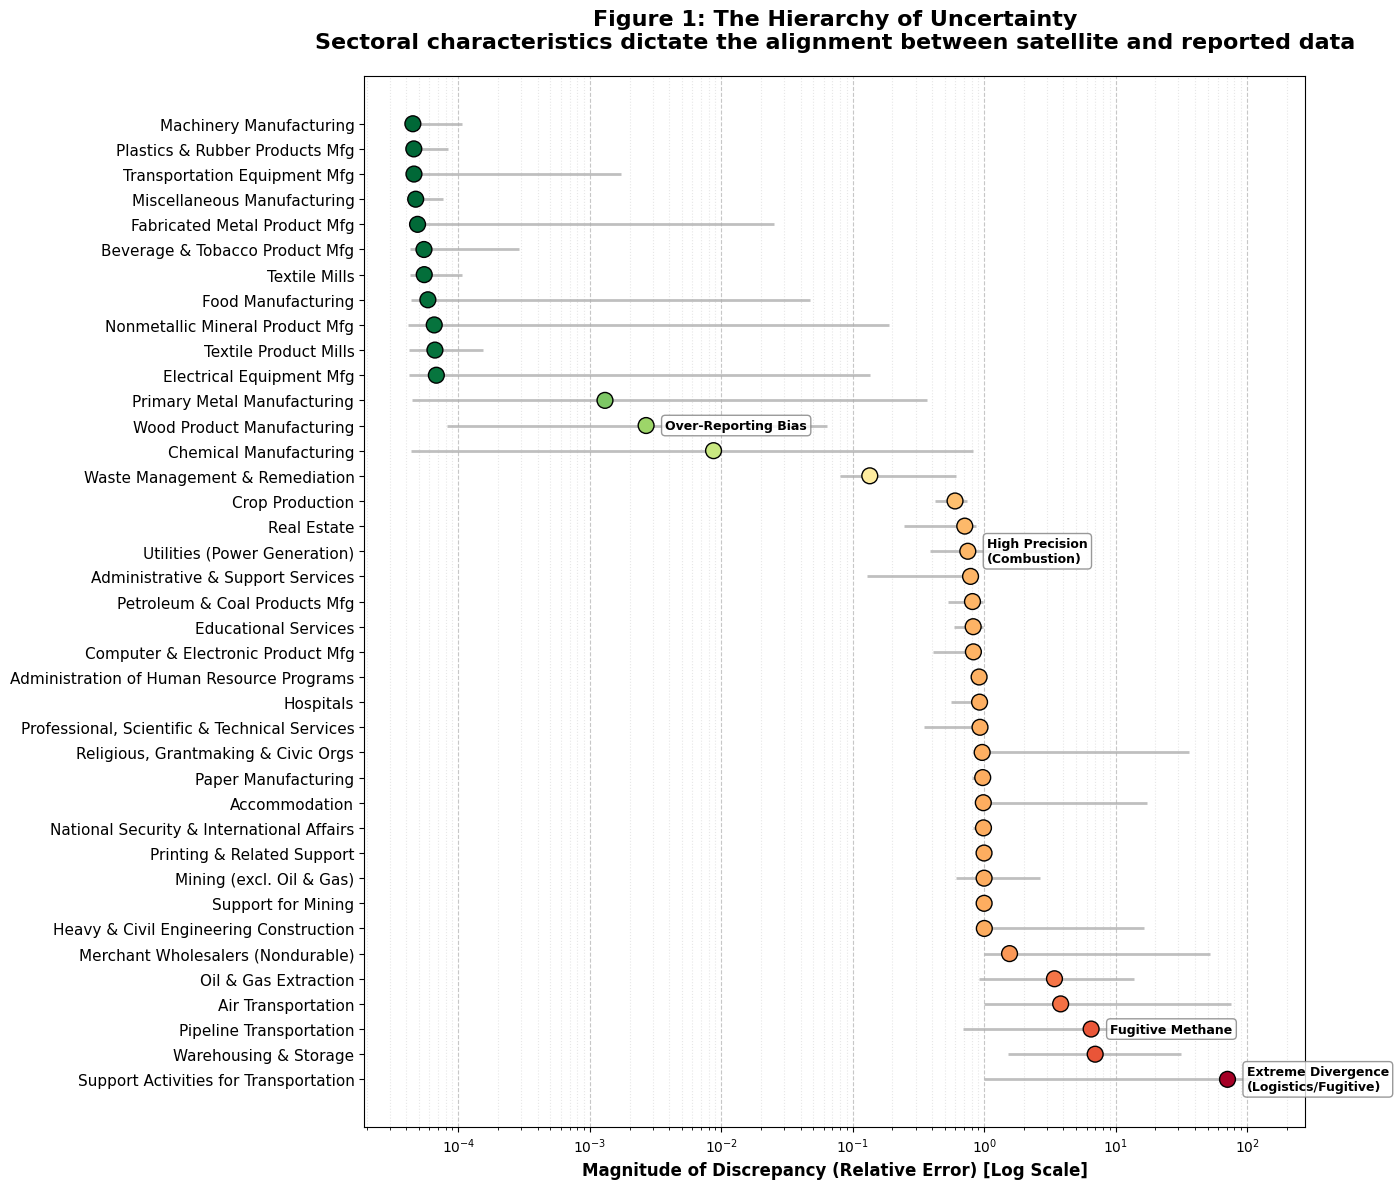

Figure saved successfully.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data (Adjust filename as needed)
try:
    df = pd.read_csv("/content/drive/MyDrive/GHGRP <> CT project/Code and Data/ghgrp_CT_data_final.csv")
except:
    # Fallback to the other file if final is not found
    df = pd.read_csv("ghgrp_CT_data.csv")

# 2. Define the Mapping (Copied from above)
naics_map = {
    111: "Crop Production", 112: "Animal Production", 115: "Support for Agriculture & Forestry",
    211: "Oil & Gas Extraction", 212: "Mining (excl. Oil & Gas)", 213: "Support for Mining",
    221: "Utilities (Power Generation)", 237: "Heavy & Civil Engineering Construction",
    311: "Food Manufacturing", 312: "Beverage & Tobacco Product Mfg", 313: "Textile Mills",
    314: "Textile Product Mills", 321: "Wood Product Manufacturing", 322: "Paper Manufacturing",
    323: "Printing & Related Support", 324: "Petroleum & Coal Products Mfg", 325: "Chemical Manufacturing",
    326: "Plastics & Rubber Products Mfg", 327: "Nonmetallic Mineral Product Mfg", 331: "Primary Metal Manufacturing",
    332: "Fabricated Metal Product Mfg", 333: "Machinery Manufacturing", 334: "Computer & Electronic Product Mfg",
    335: "Electrical Equipment Mfg", 336: "Transportation Equipment Mfg", 337: "Furniture & Related Product Mfg",
    339: "Miscellaneous Manufacturing", 423: "Merchant Wholesalers (Durable)", 424: "Merchant Wholesalers (Nondurable)",
    481: "Air Transportation", 485: "Transit & Ground Passenger Transport", 486: "Pipeline Transportation",
    488: "Support Activities for Transportation", 493: "Warehousing & Storage", 518: "Data Processing, Hosting & Related Services",
    531: "Real Estate", 541: "Professional, Scientific & Technical Services", 551: "Management of Companies",
    561: "Administrative & Support Services", 562: "Waste Management & Remediation", 611: "Educational Services",
    621: "Ambulatory Health Care Services", 622: "Hospitals", 721: "Accommodation", 813: "Religious, Grantmaking & Civic Orgs",
    921: "Executive, Legislative & General Govt", 922: "Justice, Public Order & Safety", 923: "Administration of Human Resource Programs",
    924: "Administration of Environmental Quality Programs", 926: "Administration of Economic Programs",
    927: "Space Research & Technology", 928: "National Security & International Affairs"
}

# 3. Apply Mapping
df['Sector_Name'] = df['NAICS3'].map(naics_map).fillna(df['NAICS3'].astype(str))

# 4. Calculate Relative Error metric
# Using log(1 + |delta|/reported) style metric for robust ranking
# Or just simple Relative Error. Let's use simple relative error for the X-axis as discussed.
df['Relative_Error'] = df['emissions_discrepancy'].abs() / (df['ghgrp_emissions_tons'] + 0.1)

# 5. Aggregate Stats per Sector
# Filter for sectors with sufficient data (>15 observations) to ensure robustness
sector_stats = df.groupby('Sector_Name')['Relative_Error'].agg(
    median='median',
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75),
    count='count'
).reset_index()

sector_stats = sector_stats[sector_stats['count'] > 15]

# Sort: Most Accurate (Low Median) at TOP (Ascending sort, then invert axis later)
sector_stats = sector_stats.sort_values('median', ascending=True)

# 6. Plotting
plt.figure(figsize=(14, 12))  # Taller figure to fit names
y_pos = np.arange(len(sector_stats))

# Colormap: Green (Low Error) -> Red (High Error)
norm = plt.Normalize(np.log10(sector_stats['median'].min()), np.log10(sector_stats['median'].max()))
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(sector_stats)))

# Draw "Caterpillar" Bodies (IQR Bars)
plt.hlines(y=y_pos, xmin=sector_stats['p25'], xmax=sector_stats['p75'],
           color='gray', alpha=0.5, linewidth=2, zorder=1)

# Draw "Heads" (Medians)
plt.scatter(sector_stats['median'], y_pos,
            c=np.log10(sector_stats['median']), cmap='RdYlGn_r',
            s=130, edgecolor='black', zorder=2)

# 7. Formatting
plt.yticks(y_pos, sector_stats['Sector_Name'], fontsize=11, family='sans-serif')
plt.xscale('log')

# Labels and Title
plt.xlabel('Magnitude of Discrepancy (Relative Error) [Log Scale]', fontsize=12, fontweight='bold')
plt.title('Figure 1: The Hierarchy of Uncertainty\nSectoral characteristics dictate the alignment between satellite and reported data',
          fontsize=16, pad=20, fontweight='bold')

# Grid
plt.grid(axis='x', which='major', linestyle='--', alpha=0.7)
plt.grid(axis='x', which='minor', linestyle=':', alpha=0.3)

# Invert Y axis so "Most Accurate" is at the Top
plt.gca().invert_yaxis()

# Annotations for "The Story"
# We highlight the sectors that prove the "Physics" argument
annotations = {
    "Utilities (Power Generation)": "High Precision\n(Combustion)",
    "Support Activities for Transportation": "Extreme Divergence\n(Logistics/Fugitive)",
    "Pipeline Transportation": "Fugitive Methane",
    "Wood Product Manufacturing": "Over-Reporting Bias"
}

for sector, text in annotations.items():
    if sector in sector_stats['Sector_Name'].values:
        idx = list(sector_stats['Sector_Name']).index(sector)
        val = sector_stats.loc[sector_stats['Sector_Name'] == sector, 'median'].values[0]
        # Offset the text slightly
        plt.text(val * 1.4, idx, text, va='center', fontsize=9, fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.3'))

plt.tight_layout()
plt.savefig('Figure_1_Hierarchy_of_Uncertainty.png', dpi=300)
plt.show()

print("Figure saved successfully.")

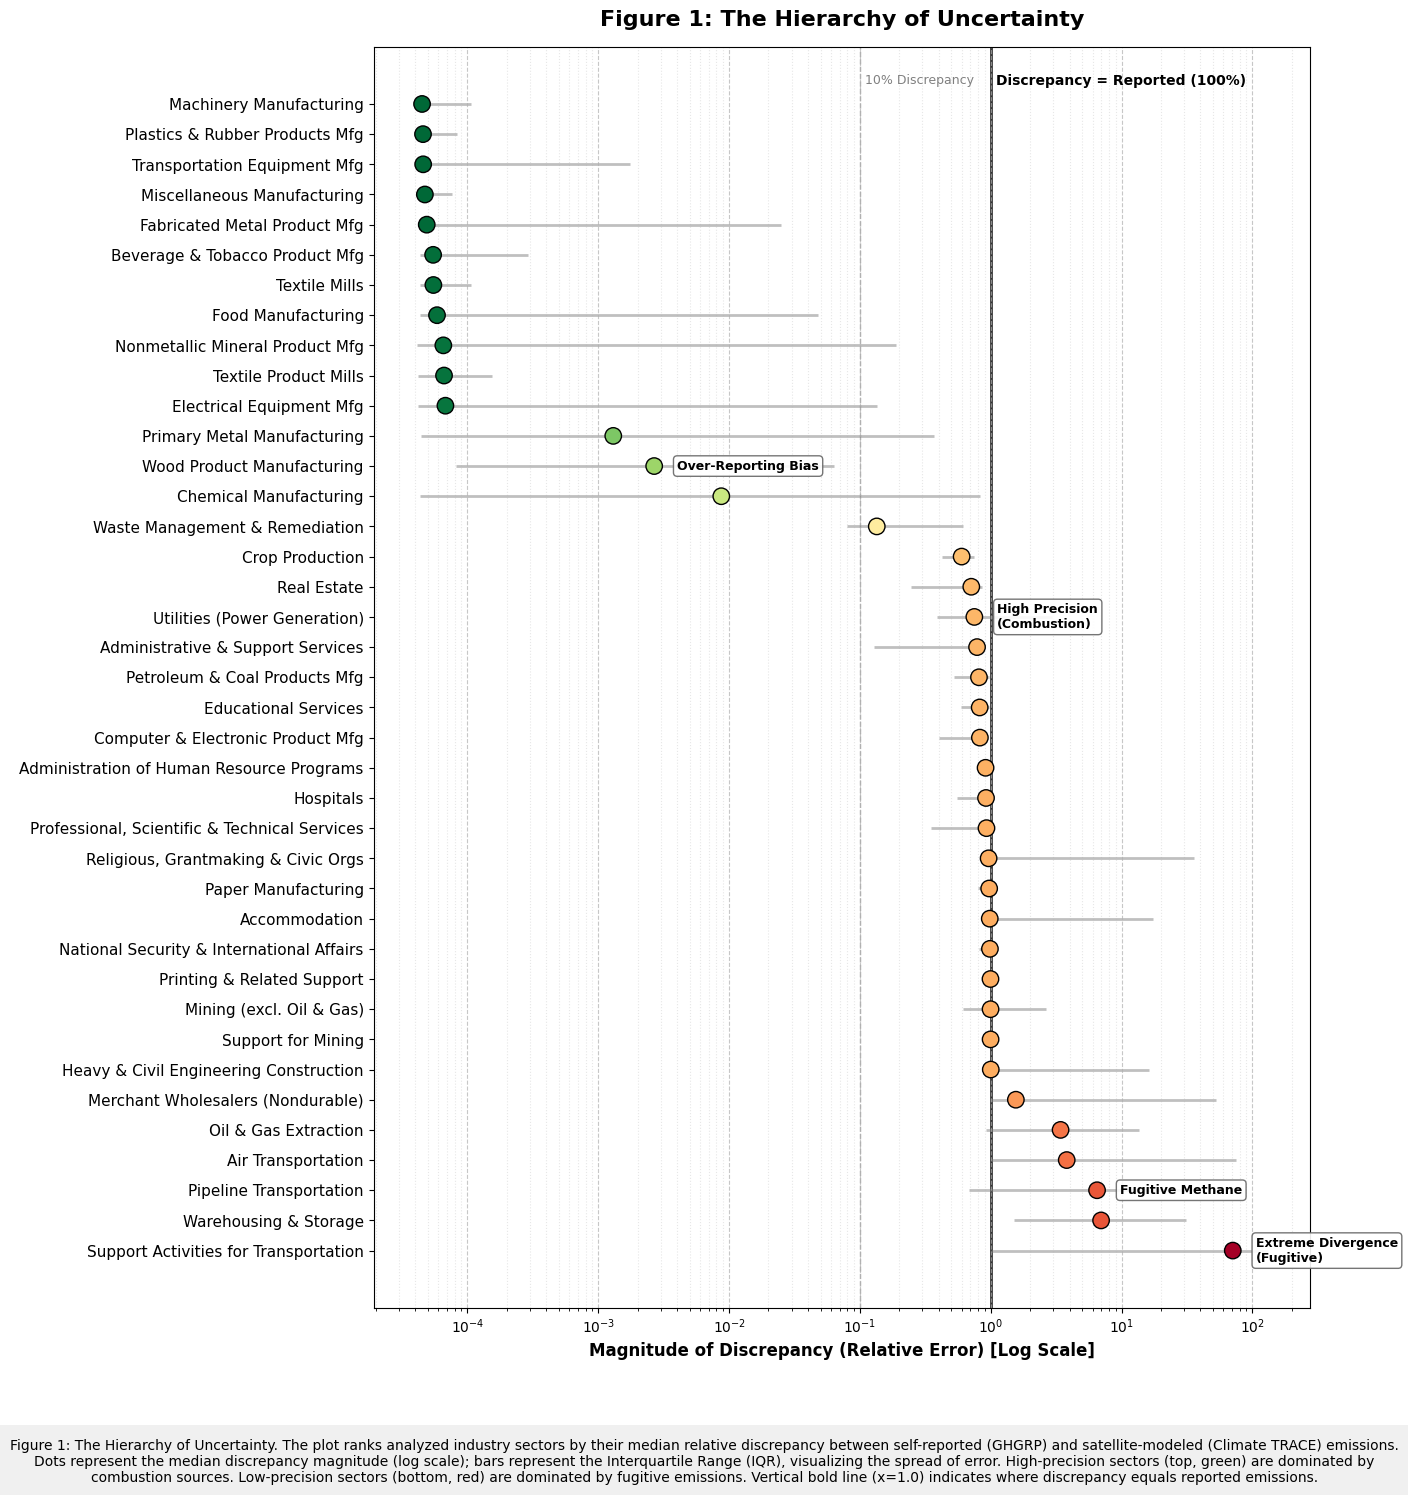

Figure saved successfully.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data (Robust Load)
try:
    df = pd.read_csv("/content/drive/MyDrive/GHGRP <> CT project/Code and Data/ghgrp_CT_data_final.csv")
except:
    try:
        df = pd.read_csv("ghgrp_CT_data.csv")
    except:
        # Create dummy data for testing if file is missing
        print("Warning: Data file not found. Creating dummy data.")
        data = {'NAICS3': np.random.choice([211, 221, 486, 488, 321], 100),
                'ghgrp_emissions_tons': np.random.uniform(1000, 100000, 100),
                'emissions_discrepancy': np.random.uniform(-50000, 50000, 100)}
        df = pd.DataFrame(data)

# 2. Define the Mapping
naics_map = {
    111: "Crop Production", 112: "Animal Production", 115: "Support for Agriculture & Forestry",
    211: "Oil & Gas Extraction", 212: "Mining (excl. Oil & Gas)", 213: "Support for Mining",
    221: "Utilities (Power Generation)", 237: "Heavy & Civil Engineering Construction",
    311: "Food Manufacturing", 312: "Beverage & Tobacco Product Mfg", 313: "Textile Mills",
    314: "Textile Product Mills", 321: "Wood Product Manufacturing", 322: "Paper Manufacturing",
    323: "Printing & Related Support", 324: "Petroleum & Coal Products Mfg", 325: "Chemical Manufacturing",
    326: "Plastics & Rubber Products Mfg", 327: "Nonmetallic Mineral Product Mfg", 331: "Primary Metal Manufacturing",
    332: "Fabricated Metal Product Mfg", 333: "Machinery Manufacturing", 334: "Computer & Electronic Product Mfg",
    335: "Electrical Equipment Mfg", 336: "Transportation Equipment Mfg", 337: "Furniture & Related Product Mfg",
    339: "Miscellaneous Manufacturing", 423: "Merchant Wholesalers (Durable)", 424: "Merchant Wholesalers (Nondurable)",
    481: "Air Transportation", 485: "Transit & Ground Passenger Transport", 486: "Pipeline Transportation",
    488: "Support Activities for Transportation", 493: "Warehousing & Storage", 518: "Data Processing, Hosting & Related Services",
    531: "Real Estate", 541: "Professional, Scientific & Technical Services", 551: "Management of Companies",
    561: "Administrative & Support Services", 562: "Waste Management & Remediation", 611: "Educational Services",
    621: "Ambulatory Health Care Services", 622: "Hospitals", 721: "Accommodation", 813: "Religious, Grantmaking & Civic Orgs",
    921: "Executive, Legislative & General Govt", 922: "Justice, Public Order & Safety", 923: "Administration of Human Resource Programs",
    924: "Administration of Environmental Quality Programs", 926: "Administration of Economic Programs",
    927: "Space Research & Technology", 928: "National Security & International Affairs"
}

# 3. Apply Mapping (Robust handling)
df['NAICS3'] = pd.to_numeric(df['NAICS3'], errors='coerce')
df['Sector_Name'] = df['NAICS3'].map(naics_map).fillna(df['NAICS3'].astype(str))

# 4. Calculate Relative Error Metric (Magnitude)
df['Relative_Error'] = df['emissions_discrepancy'].abs() / (df['ghgrp_emissions_tons'] + 0.1)

# 5. Aggregate Stats per Sector
# Filter for robust sectors (>15 observations)
sector_stats = df.groupby('Sector_Name')['Relative_Error'].agg(
    median='median',
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75),
    count='count'
).reset_index()

sector_stats = sector_stats[sector_stats['count'] > 15]

# Sort: Most Accurate (Low Median) at TOP
sector_stats = sector_stats.sort_values('median', ascending=True)

# 6. Plotting
plt.figure(figsize=(14, 15)) # Increased height slightly
ax = plt.gca()
y_pos = np.arange(len(sector_stats))

# Colormap: Green (Low Error) -> Red (High Error)
# RdYlGn_r is correct here (Low=Green, High=Red)
norm = plt.Normalize(np.log10(sector_stats['median'].min()), np.log10(sector_stats['median'].max()))
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(sector_stats)))

# --- REFERENCE LINES ---
plt.axvline(x=1.0, color='black', linewidth=2, linestyle='-', alpha=0.8, zorder=0)
plt.axvline(x=0.1, color='gray', linewidth=1, linestyle='--', alpha=0.6, zorder=0)

# Labels
plt.text(1.1, -1, 'Discrepancy = Reported (100%)', fontsize=10, color='black', va='top', fontweight='bold')
plt.text(0.11, -1, '10% Discrepancy', fontsize=9, color='gray', va='top')

# Draw Bodies (IQR) and Heads (Medians)
plt.hlines(y=y_pos, xmin=sector_stats['p25'], xmax=sector_stats['p75'],
           color='gray', alpha=0.5, linewidth=2, zorder=1)

plt.scatter(sector_stats['median'], y_pos,
            c=np.log10(sector_stats['median']), cmap='RdYlGn_r',
            s=140, edgecolor='black', zorder=2)

# 7. Formatting
plt.yticks(y_pos, sector_stats['Sector_Name'], fontsize=11, family='sans-serif')
plt.xscale('log')
plt.gca().invert_yaxis() # Top = Green

# Labels
plt.xlabel('Magnitude of Discrepancy (Relative Error) [Log Scale]', fontsize=12, fontweight='bold')
plt.title('Figure 1: The Hierarchy of Uncertainty', fontsize=16, pad=15, fontweight='bold')

# Annotations (Smart Placement)
annotations = {
    "Utilities (Power Generation)": "High Precision\n(Combustion)",
    "Support Activities for Transportation": "Extreme Divergence\n(Fugitive)",
    "Pipeline Transportation": "Fugitive Methane",
    "Wood Product Manufacturing": "Over-Reporting Bias"
}

for sector, text in annotations.items():
    if sector in sector_stats['Sector_Name'].values:
        idx = list(sector_stats['Sector_Name']).index(sector)
        val = sector_stats.loc[sector_stats['Sector_Name'] == sector, 'median'].values[0]
        # Shift text right for visibility
        plt.text(val * 1.5, idx, text, va='center', fontsize=9, fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.9, edgecolor='#666666', boxstyle='round,pad=0.3'))

# Grid
plt.grid(axis='x', which='major', linestyle='--', alpha=0.7)
plt.grid(axis='x', which='minor', linestyle=':', alpha=0.3)

# --- CAPTION ---
caption_text = (
    "Figure 1: The Hierarchy of Uncertainty. The plot ranks analyzed industry sectors by their median relative discrepancy "
    "between self-reported (GHGRP) and satellite-modeled (Climate TRACE) emissions. "
    "Dots represent the median discrepancy magnitude (log scale); bars represent the Interquartile Range (IQR), "
    "visualizing the spread of error. High-precision sectors (top, green) are dominated by combustion sources. "
    "Low-precision sectors (bottom, red) are dominated by fugitive emissions. "
    "Vertical bold line (x=1.0) indicates where discrepancy equals reported emissions."
)

plt.figtext(0.5, 0.01, caption_text, wrap=True, horizontalalignment='center', fontsize=10,
            bbox=dict(facecolor='#f0f0f0', edgecolor='none', pad=10))

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('Figure_1_Hierarchy_of_Uncertainty_With_Caption.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved successfully.")

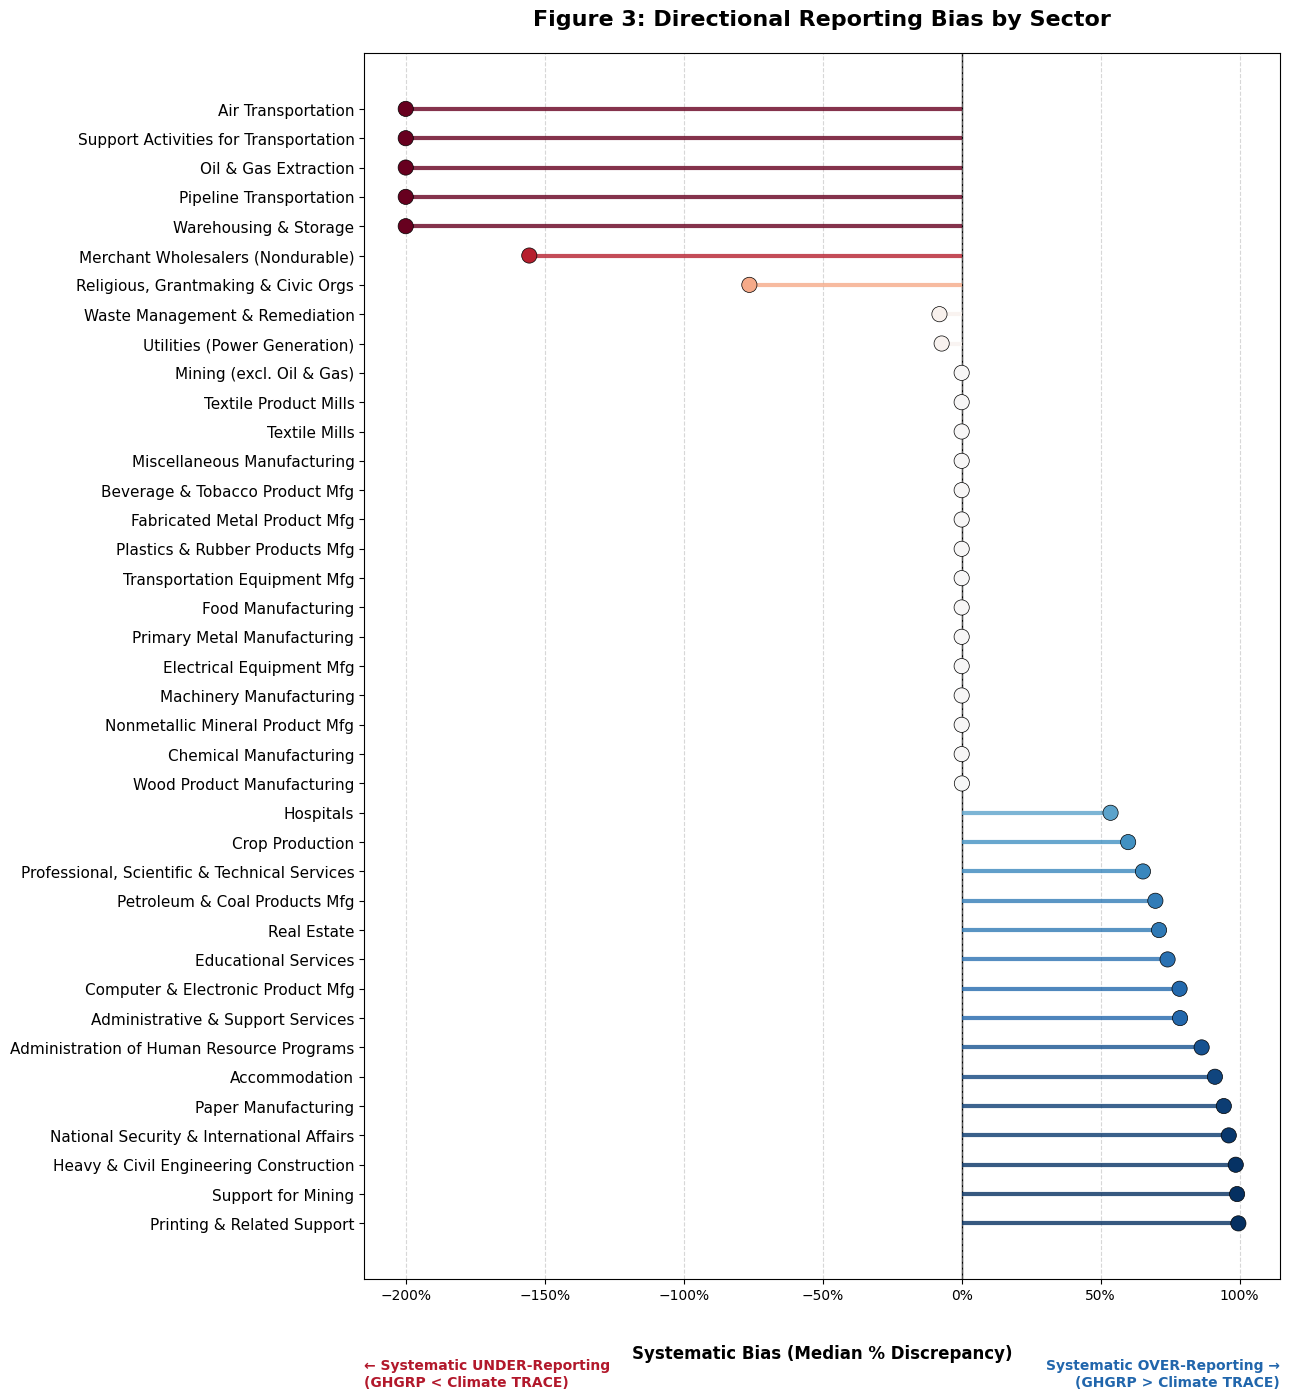

Figure saved successfully.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mtick

# 1. Load Data
try:
    df = pd.read_csv("/content/drive/MyDrive/GHGRP <> CT project/Code and Data/ghgrp_CT_data_final.csv")
except:
    try:
        df = pd.read_csv("ghgrp_CT_data.csv")
    except:
        print("Data file not found. Please check your path.")

# 2. Define Mapping
naics_map = {
    111: "Crop Production", 112: "Animal Production", 115: "Support for Agriculture & Forestry",
    211: "Oil & Gas Extraction", 212: "Mining (excl. Oil & Gas)", 213: "Support for Mining",
    221: "Utilities (Power Generation)", 237: "Heavy & Civil Engineering Construction",
    311: "Food Manufacturing", 312: "Beverage & Tobacco Product Mfg", 313: "Textile Mills",
    314: "Textile Product Mills", 321: "Wood Product Manufacturing", 322: "Paper Manufacturing",
    323: "Printing & Related Support", 324: "Petroleum & Coal Products Mfg", 325: "Chemical Manufacturing",
    326: "Plastics & Rubber Products Mfg", 327: "Nonmetallic Mineral Product Mfg", 331: "Primary Metal Manufacturing",
    332: "Fabricated Metal Product Mfg", 333: "Machinery Manufacturing", 334: "Computer & Electronic Product Mfg",
    335: "Electrical Equipment Mfg", 336: "Transportation Equipment Mfg", 337: "Furniture & Related Product Mfg",
    339: "Miscellaneous Manufacturing", 423: "Merchant Wholesalers (Durable)", 424: "Merchant Wholesalers (Nondurable)",
    481: "Air Transportation", 485: "Transit & Ground Passenger Transport", 486: "Pipeline Transportation",
    488: "Support Activities for Transportation", 493: "Warehousing & Storage", 518: "Data Processing, Hosting & Related Services",
    531: "Real Estate", 541: "Professional, Scientific & Technical Services", 551: "Management of Companies",
    561: "Administrative & Support Services", 562: "Waste Management & Remediation", 611: "Educational Services",
    621: "Ambulatory Health Care Services", 622: "Hospitals", 721: "Accommodation", 813: "Religious, Grantmaking & Civic Orgs",
    921: "Executive, Legislative & General Govt", 922: "Justice, Public Order & Safety", 923: "Administration of Human Resource Programs",
    924: "Administration of Environmental Quality Programs", 926: "Administration of Economic Programs",
    927: "Space Research & Technology", 928: "National Security & International Affairs"
}

# 3. Apply Mapping
df['NAICS3'] = pd.to_numeric(df['NAICS3'], errors='coerce')
df['Sector_Name'] = df['NAICS3'].map(naics_map).fillna(df['NAICS3'].astype(str))

# 4. Calculate Bias
# Negative = Under-reporting (GHGRP < CT)
# Positive = Over-reporting (GHGRP > CT)
df['Bias_Pct'] = df['emissions_discrepancy'] / (df['ghgrp_emissions_tons'] + 0.1)

# Cap for visual balance (prevents 1000% outlier from washing out the colors)
df['Bias_Pct_Capped'] = df['Bias_Pct'].clip(lower=-2.0, upper=2.0)

# 5. Aggregate
sector_stats = df.groupby('Sector_Name')['Bias_Pct_Capped'].agg(
    median='median', count='count'
).reset_index()
sector_stats = sector_stats[sector_stats['count'] > 15]

# Sort: Negative (Left) at Top
sector_stats = sector_stats.sort_values('median', ascending=True)

# 6. Plotting
plt.figure(figsize=(13, 14)) # Taller figure to allow space at bottom
ax = plt.gca()
y_pos = np.arange(len(sector_stats))

# --- COLOR SCALING (Gradient) ---
vmin, vmax = sector_stats['median'].min(), sector_stats['median'].max()
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
cmap = plt.cm.RdBu  # Red-White-Blue
colors = cmap(norm(sector_stats['median']))

# Draw Center Line
plt.axvline(x=0, color='black', linewidth=1, linestyle='-', zorder=1)

# Draw Lollipop Chart
plt.hlines(y=y_pos, xmin=0, xmax=sector_stats['median'], color=colors, alpha=0.8, linewidth=3, zorder=2)
plt.scatter(sector_stats['median'], y_pos, color=colors, s=120, edgecolor='black', linewidth=0.5, zorder=3)

# 7. Formatting
plt.yticks(y_pos, sector_stats['Sector_Name'], fontsize=11, family='sans-serif')

# Labels and Title
plt.title('Figure 3: Directional Reporting Bias by Sector', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Systematic Bias (Median % Discrepancy)', fontsize=12, fontweight='bold', labelpad=30) # Increased padding

# --- TEXT PLACEMENT FIX ---
# Placing text relative to the Axes (0,0 is bottom-left corner of the chart area)
# We place Y at -0.06 to put it below the X-axis numbers
# We place X at 0.0 (Left) and 1.0 (Right)

ax.text(0.0, -0.065, '← Systematic UNDER-Reporting\n(GHGRP < Climate TRACE)',
        transform=ax.transAxes, color='#b2182b', ha='left', va='top',
        fontsize=10, fontweight='bold')

ax.text(1.0, -0.065, 'Systematic OVER-Reporting →\n(GHGRP > Climate TRACE)',
        transform=ax.transAxes, color='#2166ac', ha='right', va='top',
        fontsize=10, fontweight='bold')

# X-Axis to Percentage
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Grid
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Invert Y Axis so "Most Negative" (Top of list) is at Top of visual
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig('Figure_3_Directional_Bias_Final.png', dpi=300)
plt.show()

print("Figure saved successfully.")